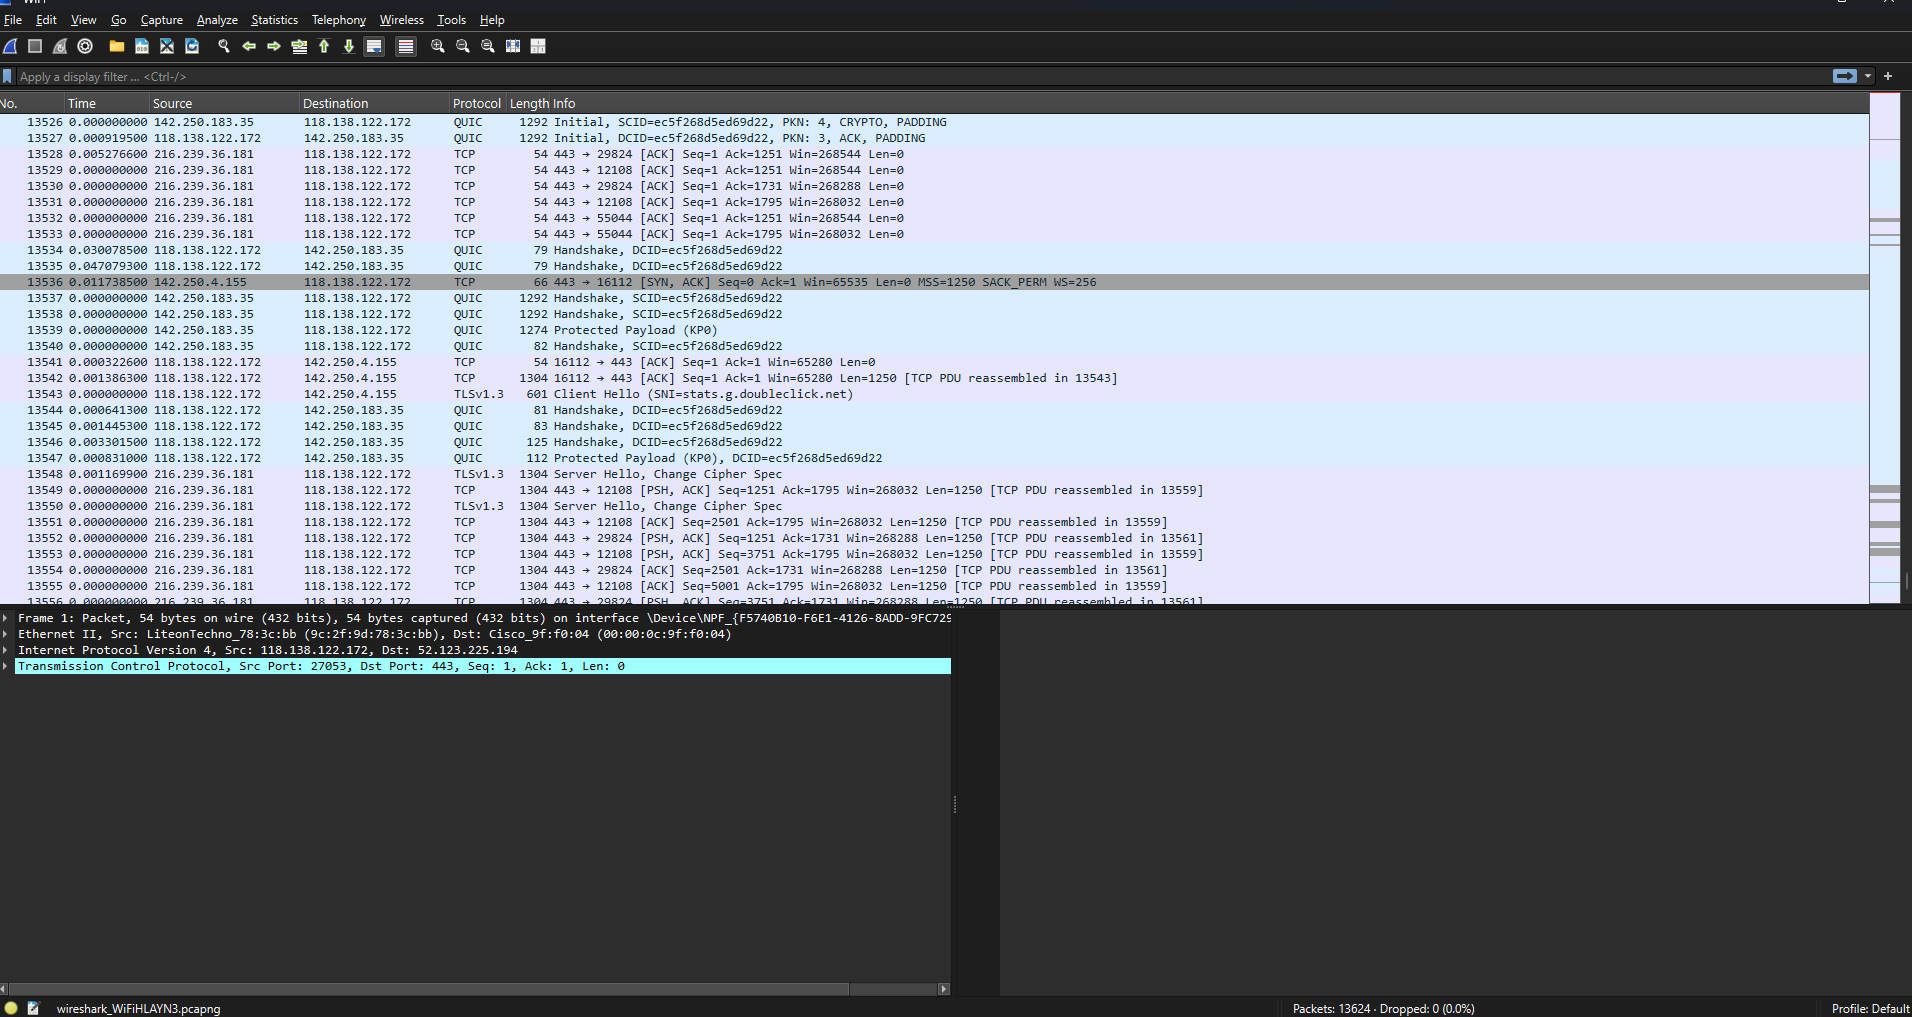

Inter-arrival samples: 13613
Estimated exponential mean (mu): 0.001693 s
Estimated exponential rate (lambda): 590.734520 1/s
Total capture time from inter-arrivals: 23.044192 s
Intervals N: 100
Estimated Poisson lambda per interval: 136.1300
Observed count mean: 136.1300, variance: 92937.9324


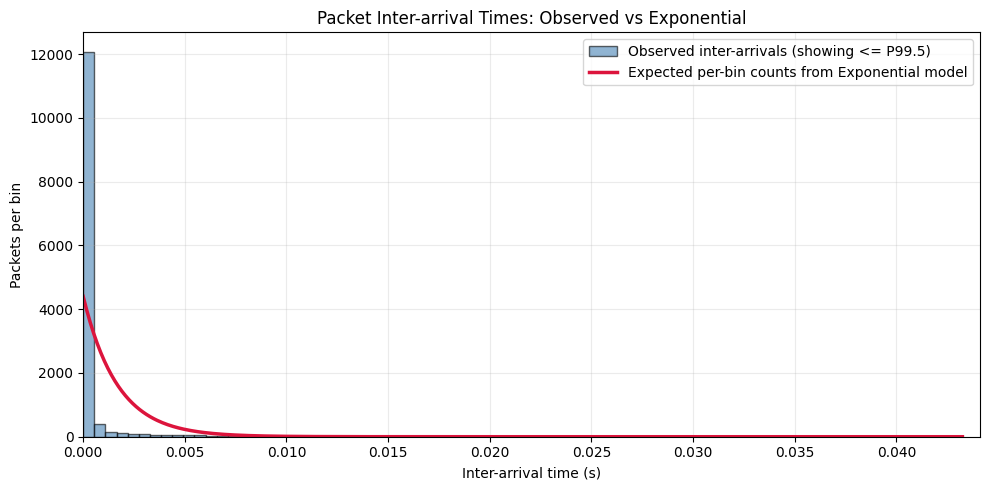

Figure 1 visible range: 0 to 0.043251 s (P99.5), showing 13544/13613 samples; 69 samples are in the right tail beyond this range.


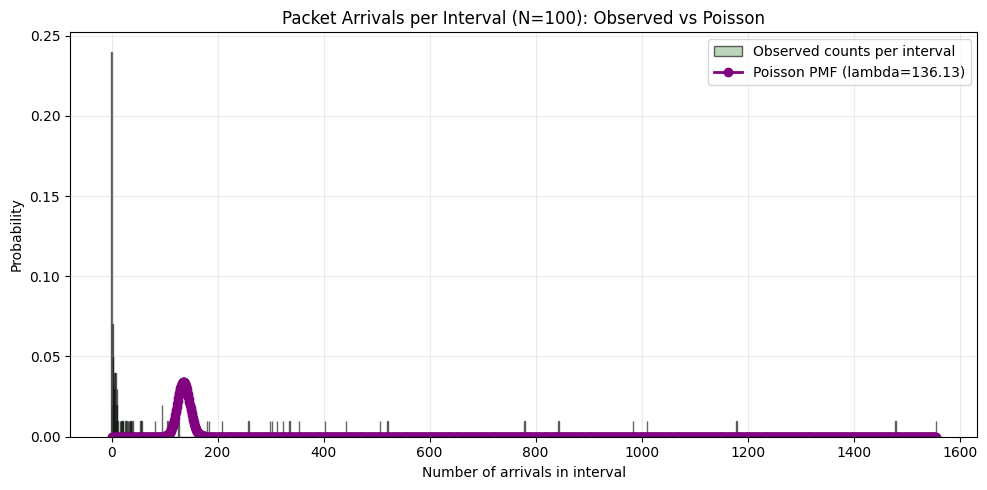

In [9]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Wireshark export (Time column contains inter-arrival times)
df = pd.read_csv("wireshark.csv")
interarrival = pd.to_numeric(df["Time"], errors="coerce").dropna().to_numpy()

# Keep non-negative inter-arrival samples (0 is valid in packet traces)
interarrival = interarrival[interarrival >= 0]

if interarrival.size == 0:
    raise ValueError("No valid inter-arrival times found in the Time column.")

# Exponential model parameter estimate: mean inter-arrival time
mu_hat = interarrival.mean()
if mu_hat <= 0:
    raise ValueError("Mean inter-arrival time is zero; cannot fit exponential model.")
lambda_hat = 1.0 / mu_hat

# Build absolute arrival times from inter-arrivals
arrival_times = np.cumsum(interarrival)
total_time = arrival_times[-1]

# Number of equal time intervals (change if needed)
N = 100
interval_edges = np.linspace(0, total_time, N + 1)
counts_per_interval, _ = np.histogram(arrival_times, bins=interval_edges)

# Poisson model parameter: mean arrivals per interval
poisson_lambda = counts_per_interval.mean()

print(f"Inter-arrival samples: {len(interarrival)}")
print(f"Estimated exponential mean (mu): {mu_hat:.6f} s")
print(f"Estimated exponential rate (lambda): {lambda_hat:.6f} 1/s")
print(f"Total capture time from inter-arrivals: {total_time:.6f} s")
print(f"Intervals N: {N}")
print(f"Estimated Poisson lambda per interval: {poisson_lambda:.4f}")
print(f"Observed count mean: {counts_per_interval.mean():.4f}, variance: {counts_per_interval.var(ddof=1):.4f}")

# ---------------- Figure 1: Inter-arrival histogram + exponential model ----------------
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the dense main body (up to percentile) with many bins, so bars are visible
plot_percentile = 99.5
x_max = np.percentile(interarrival, plot_percentile)
tail_count = np.sum(interarrival > x_max)
visible_count = interarrival.size - tail_count
bin_edges = np.linspace(0, x_max, 80)

hist_counts, hist_edges, _ = ax.hist(
    interarrival,
    bins=bin_edges,
    density=False,
    alpha=0.6,
    color="steelblue",
    edgecolor="black",
    label=f"Observed inter-arrivals (showing <= P{plot_percentile})",
)

# Overlay expected BIN COUNTS under exponential model (not PDF density)
bin_width = hist_edges[1] - hist_edges[0]
x = np.linspace(0, x_max, 500)
exp_expected_counts = len(interarrival) * bin_width * lambda_hat * np.exp(-lambda_hat * x)
ax.plot(
    x,
    exp_expected_counts,
    color="crimson",
    linewidth=2.5,
    label="Expected per-bin counts from Exponential model",
)

ax.set_title("Packet Inter-arrival Times: Observed vs Exponential")
ax.set_xlabel("Inter-arrival time (s)")
ax.set_ylabel("Packets per bin")
ax.grid(alpha=0.25)
ax.legend()
ax.set_xlim(0, x_max * 1.02)
plt.tight_layout()
plt.show()

print(
    f"Figure 1 visible range: 0 to {x_max:.6f} s (P{plot_percentile}), "
    f"showing {visible_count}/{len(interarrival)} samples; "
    f"{tail_count} samples are in the right tail beyond this range."
)

# ---------------- Figure 2: Count histogram + Poisson PMF ----------------
fig, ax = plt.subplots(figsize=(10, 5))

k_min = int(counts_per_interval.min())
k_max = int(counts_per_interval.max())
count_bins = np.arange(k_min - 0.5, k_max + 1.5, 1)

# Relative-frequency histogram so it is comparable to PMF values
ax.hist(
    counts_per_interval,
    bins=count_bins,
    density=True,
    alpha=0.6,
    color="darkseagreen",
    edgecolor="black",
    label="Observed counts per interval",
)

k_vals = np.arange(k_min, k_max + 1)

# Numerically stable Poisson PMF via log-space to avoid factorial overflow
if poisson_lambda == 0:
    poisson_pmf = np.where(k_vals == 0, 1.0, 0.0)
else:
    log_pmf = -poisson_lambda + k_vals * np.log(poisson_lambda) - np.array([math.lgamma(k + 1) for k in k_vals])
    poisson_pmf = np.exp(log_pmf)

ax.plot(
    k_vals,
    poisson_pmf,
    "o-",
    color="purple",
    linewidth=2,
    label=f"Poisson PMF (lambda={poisson_lambda:.2f})",
)

ax.set_title(f"Packet Arrivals per Interval (N={N}): Observed vs Poisson")
ax.set_xlabel("Number of arrivals in interval")
ax.set_ylabel("Probability")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()